INX Future Inc. Employee Performance Analysis

Machine Learning Model Training

The notebook focuses on preparing the employee performance dataset for machine learning and training classification models to predict employee performance ratings.

The target variable for this project is the Performance Rating. The data will be divided into input features and the target variable, categorical variables will be encoded and the data will be divided into training and testing sets.

Several classification algorithms will then be trained and evaluated in order to identify the model that provides the most suitable performance for predicting the employee performance ratings.

Import  Libraries

The required Python libraries are imported for data manipulation,preprocessing,model training and model evaluation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix)

**Load the Dataset**

The INX Future Inc. employee performance dataset is loaded into a Pandas DataFrame for preprocessing and machine learning.

In [3]:
df = pd.read_excel("/content/INX_Future_Inc_Employee_Performance.xlsx")

In [4]:
df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


**Separation of Features and Target Variable**

The dataset is divided into input features and the target variable.

The input features, represented by X, contain the employee characteristics that will be used by the machine-learning models to make predictions.

The target variable, represented by y, is PerformanceRating, which represents the employee performance rating that the models will predict.

In [5]:
X = df.drop('PerformanceRating', axis=1)
y = df['PerformanceRating']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1200, 27)
Target shape: (1200,)


**Removal of Employee Identifier**

The employee identification number is used only to uniquely identify individual employees. It does not provide meaningful information about employee performance.Therefore, the employee identifier is excluded from the input features to prevent it from influencing the machine-learning models.

In [6]:
X.columns.tolist()

['EmpNumber',
 'Age',
 'Gender',
 'EducationBackground',
 'MaritalStatus',
 'EmpDepartment',
 'EmpJobRole',
 'BusinessTravelFrequency',
 'DistanceFromHome',
 'EmpEducationLevel',
 'EmpEnvironmentSatisfaction',
 'EmpHourlyRate',
 'EmpJobInvolvement',
 'EmpJobLevel',
 'EmpJobSatisfaction',
 'NumCompaniesWorked',
 'OverTime',
 'EmpLastSalaryHikePercent',
 'EmpRelationshipSatisfaction',
 'TotalWorkExperienceInYears',
 'TrainingTimesLastYear',
 'EmpWorkLifeBalance',
 'ExperienceYearsAtThisCompany',
 'ExperienceYearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager',
 'Attrition']

In [7]:
X = X.drop('EmpNumber', axis=1)

In [8]:
X.head()

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,...,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,4,...,12,4,10,2,2,10,7,0,8,No
1,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,4,...,12,4,20,2,3,7,7,1,7,No
2,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,4,...,21,3,20,2,3,18,13,1,12,No
3,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,2,...,15,2,23,2,2,21,6,12,6,No
4,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,1,...,14,4,10,1,3,2,2,2,2,No


**Identification of Categorical Variables**

Categorical variables contain values that represent groups or categories such as department, gender, job role and other employee characteristics.

Machine Learning algorithms require these categorical values to be represented in numerical form. Therefore the categorical variables are identified before encoding.

In [9]:
categorical_features = X.select_dtypes(
    include='object'
).columns

categorical_features

Index(['Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment',
       'EmpJobRole', 'BusinessTravelFrequency', 'OverTime', 'Attrition'],
      dtype='object')

**Identification of Numerical Variables**

Numerical variables contain quantitative values such as age, years at the company, and salary-related measures.

These variables are identified separately because numerical features can be used for numerical calculations and may require scaling depending on the machine Learning algorithm being used.

In [10]:
numerical_features = X.select_dtypes(
    include=np.number
).columns

numerical_features

Index(['Age', 'DistanceFromHome', 'EmpEducationLevel',
       'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement',
       'EmpJobLevel', 'EmpJobSatisfaction', 'NumCompaniesWorked',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

**Encode Categorical Variables**

Categorical variables can't be directly processed by most of the machine-learning algorithms in their original text format.One-hot encoding is therefore used to convert categorical variables into numerical binary variables. The drop first option is used to remove one category from each encoded variable and reduce unnecessary redundancy.

In [11]:
X = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

In [12]:
X.head()

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,...,EmpJobRole_Sales Executive,EmpJobRole_Sales Representative,EmpJobRole_Senior Developer,EmpJobRole_Senior Manager R&D,EmpJobRole_Technical Architect,EmpJobRole_Technical Lead,BusinessTravelFrequency_Travel_Frequently,BusinessTravelFrequency_Travel_Rarely,OverTime_Yes,Attrition_Yes
0,32,10,3,4,55,3,2,4,1,12,...,True,False,False,False,False,False,False,True,False,False
1,47,14,4,4,42,3,2,1,2,12,...,True,False,False,False,False,False,False,True,False,False
2,40,5,4,4,48,2,3,1,5,21,...,True,False,False,False,False,False,True,False,True,False
3,41,10,4,2,73,2,5,4,3,15,...,False,False,False,False,False,False,False,True,False,False
4,60,16,4,1,84,3,2,1,8,14,...,True,False,False,False,False,False,False,True,False,False


In [13]:
X.shape

(1200, 53)

**Verification of Processed Features**

After encoding the categorical variables, the resulting feature dataset is examined in order to confirm that the variables are now represented in a numerical format and also are suitable for machine learning algorithms.

In [14]:
X.dtypes.value_counts()

,count
bool,35
int64,18


**Splitting the Dataset into Training and Testing Sets**

The dataset is divided into training and testing sets.

The training dataset is used to train the machine learning models while the testing dataset is used to evaluate how well the trained models perform on previously unseen data.


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

**Feature Scaling**

Feature scaling is applied to the training and testing data used by Logistic Regression.

Standardization transforms the features so that they have a mean close to zero and a standard deviation close to one. This helps prevent variables with larger numerical ranges from disproportionately influencing the Logistic Regression model.

Tree-based models do not require feature scaling, so the unscaled encoded features will be used for those models.

The scaler is fitted only on the training data and then applied to both the training and testing data to prevent data leakage.

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Logistical Regression**

Logistical Regression is a classification algorithm used to predict employee performance ratings.


In [17]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

In [18]:
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred, average='weighted', zero_division=0)
lr_recall = recall_score(y_test, lr_pred, average='weighted', zero_division=0)
lr_f1 = f1_score(y_test, lr_pred, average='weighted', zero_division=0)

print("Logistic Regression")
print("Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1-score:", lr_f1)

Logistic Regression
Accuracy: 0.825
Precision: 0.8165536347517731
Recall: 0.825
F1-score: 0.8177380608962194


**Decision Tree**

Decision tree is a classification algorithm that makes prediction by creating a series of decision rules based on the input features.

In [19]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [20]:
dt_accuracy = accuracy_score(y_test, dt_pred)

dt_precision = precision_score(
    y_test,
    dt_pred,
    average='weighted',
    zero_division=0
)

dt_recall = recall_score(
    y_test,
    dt_pred,
    average='weighted',
    zero_division=0
)

dt_f1 = f1_score(
    y_test,
    dt_pred,
    average='weighted',
    zero_division=0
)

print("Decision Tree")
print("Accuracy:", dt_accuracy)
print("Precision:", dt_precision)
print("Recall:", dt_recall)
print("F1-score:", dt_f1)

Decision Tree
Accuracy: 0.9083333333333333
Precision: 0.907366819436231
Recall: 0.9083333333333333
F1-score: 0.907632635541984


**Random Forest**

Random Forest is a classification algorithm that combines multiple decision trees in order to improve prediction performance and reduce the risk of relying on a single decision tree.

In [21]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [22]:
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(
    y_test,
    rf_pred,
    average='weighted',
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    average='weighted',
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average='weighted',
    zero_division=0
)

print("Random Forest")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1-score:", rf_f1)

Random Forest
Accuracy: 0.9166666666666666
Precision: 0.9200753449527959
Recall: 0.9166666666666666
F1-score: 0.9127751774613831


Gradient Boosting

Gradient Boosting is a classification algorithm that builds multiple decision trees sequentially, with each tree improving the errors made by the previous trees.

In [23]:
gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

In [24]:
gb_accuracy = accuracy_score(y_test, gb_pred)

gb_precision = precision_score(
    y_test,
    gb_pred,
    average='weighted',
    zero_division=0
)

gb_recall = recall_score(
    y_test,
    gb_pred,
    average='weighted',
    zero_division=0
)

gb_f1 = f1_score(
    y_test,
    gb_pred,
    average='weighted',
    zero_division=0
)

print("Gradient Boosting")
print("Accuracy:", gb_accuracy)
print("Precision:", gb_precision)
print("Recall:", gb_recall)
print("F1-score:", gb_f1)

Gradient Boosting
Accuracy: 0.9375
Precision: 0.9374612351586035
Recall: 0.9375
F1-score: 0.9366549676848972


**Model Comparison**

The performance of the classification models is compared using accuracy,precision,recall and F1-score.These helps determine which model provides the most reliable predictions of employee performance ratings.

In [25]:
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Accuracy': [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        gb_accuracy
    ],
    'Precision': [
        lr_precision,
        dt_precision,
        rf_precision,
        gb_precision
    ],
    'Recall': [
        lr_recall,
        dt_recall,
        rf_recall,
        gb_recall
    ],
    'F1-score': [
        lr_f1,
        dt_f1,
        rf_f1,
        gb_f1
    ]
})

model_results = model_results.sort_values(
    by='F1-score',
    ascending=False
)

model_results

,Model,Accuracy,Precision,Recall,F1-score
3,Gradient Boosting,0.937500,0.937461,0.937500,0.936655
2,Random Forest,0.916667,0.920075,0.916667,0.912775
1,Decision Tree,0.908333,0.907367,0.908333,0.907633
0,Logistic Regression,0.825000,0.816554,0.825000,0.817738


**Model Comparison Insight**

The model comparison shows that gradient boosting achieved the highest performance across all four evaluation metrics with an accuracy of 93.75% and f1-score of 93.67%.Random forest is second best performing model followed by Decision Tree and Logistic Regression.

Gradient boosting is the best for predicting employee performance ratings.

**Confusion Matrix**

Confusion matrix is used to evaluate how well each classification model predicts the different employee performance ratings.It shows the number of correct and incorrect predictions made for each performance rating.

In [26]:
# Logistic Regression
lr_cm = confusion_matrix(y_test, lr_pred)

# Decision Tree
dt_cm = confusion_matrix(y_test, dt_pred)

# Random Forest
rf_cm = confusion_matrix(y_test, rf_pred)

# Gradient Boosting
gb_cm = confusion_matrix(y_test, gb_pred)

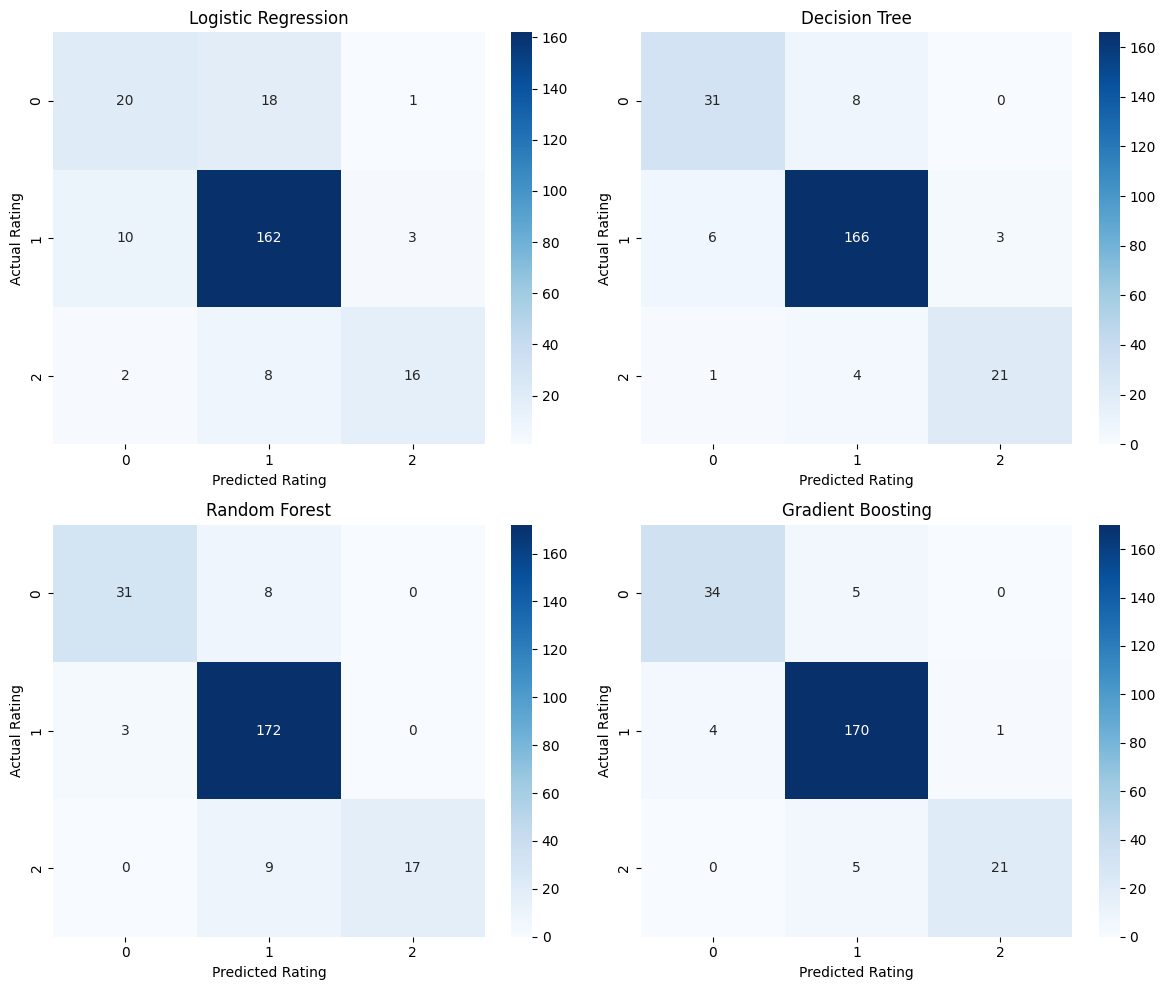

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title('Logistic Regression')
axes[0, 0].set_xlabel('Predicted Rating')
axes[0, 0].set_ylabel('Actual Rating')

sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1])
axes[0, 1].set_title('Decision Tree')
axes[0, 1].set_xlabel('Predicted Rating')
axes[0, 1].set_ylabel('Actual Rating')

sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_title('Random Forest')
axes[1, 0].set_xlabel('Predicted Rating')
axes[1, 0].set_ylabel('Actual Rating')

sns.heatmap(gb_cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1])
axes[1, 1].set_title('Gradient Boosting')
axes[1, 1].set_xlabel('Predicted Rating')
axes[1, 1].set_ylabel('Actual Rating')

plt.tight_layout()
plt.show()

**Confusion Matrix Insight**

The confusion matrix shows that Gradient Boosting achieved the strongest classification performance among the four models.The model performed well in identifying the middle performance category. Overall, the confusion matrix supports the selection of Gradient Boosting as the best performing model for predicting employee performance ratings.

**Feature Importance**

Feature importance is used to identify the variables that contribute most to the Gradient Boosting model's predictions of employee performance.Idenitfying these important features helps to determine the key factors that are  associated with employee performance and provides a useful insights for management decision making.

In [28]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
3,EmpEnvironmentSatisfaction,0.276079
9,EmpLastSalaryHikePercent,0.245261
16,YearsSinceLastPromotion,0.195727
26,EmpDepartment_Development,0.067296
13,EmpWorkLifeBalance,0.053698
15,ExperienceYearsInCurrentRole,0.041450
17,YearsWithCurrManager,0.017166
33,EmpJobRole_Developer,0.014776
14,ExperienceYearsAtThisCompany,0.011877
4,EmpHourlyRate,0.010384


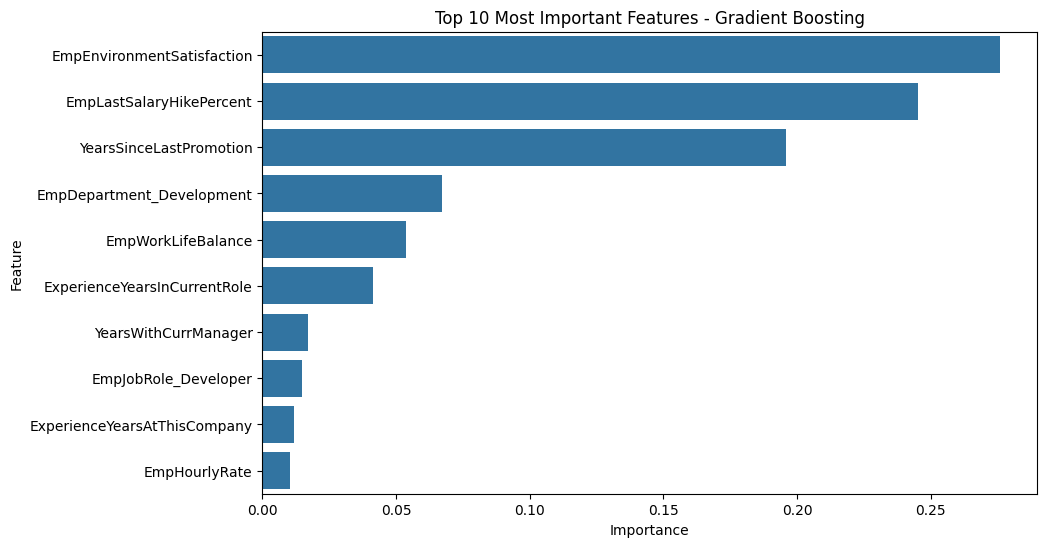

In [29]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Most Important Features - Gradient Boosting')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

**Top 3 Important factors Affecting Employee Performance**

- Employee Environmnet Satisfaction.

- Employee last slary hike percentage.

- Years since last promotion.

**Business Insights**

The results suggest that workplace environment,salary growth and career progression are important factors in predicting employee performance.INX Future Inc could therefore focus on improving the employee work environment, ensuring competitive and performance based salary increases and providing opportunities for career advancement.

**Selected Model**

Based on the model evaluation results, Gradient Boosting was selected as the final model because it achieved the highest accuracy, precision, recall and F1-score among all the other  models that were evaluated.The model achieved an accuracy of 93.75% and also an F1-score of 93.67% on the testing data.

**Final Model**

The Gradient Boosting model and the feature scaler are saved so that they can be loaded and used later in the employee performance prediction notebook.

In [30]:
import joblib

joblib.dump(gb, 'gradient_boosting_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'model_features.pkl')

print("Model, scaler, and model features successfully saved.")

Model, scaler, and model features successfully saved.


In [31]:
from google.colab import files

files.download('gradient_boosting_model.pkl')
files.download('scaler.pkl')
files.download('model_features.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>